In [28]:
import pandas as pd
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt

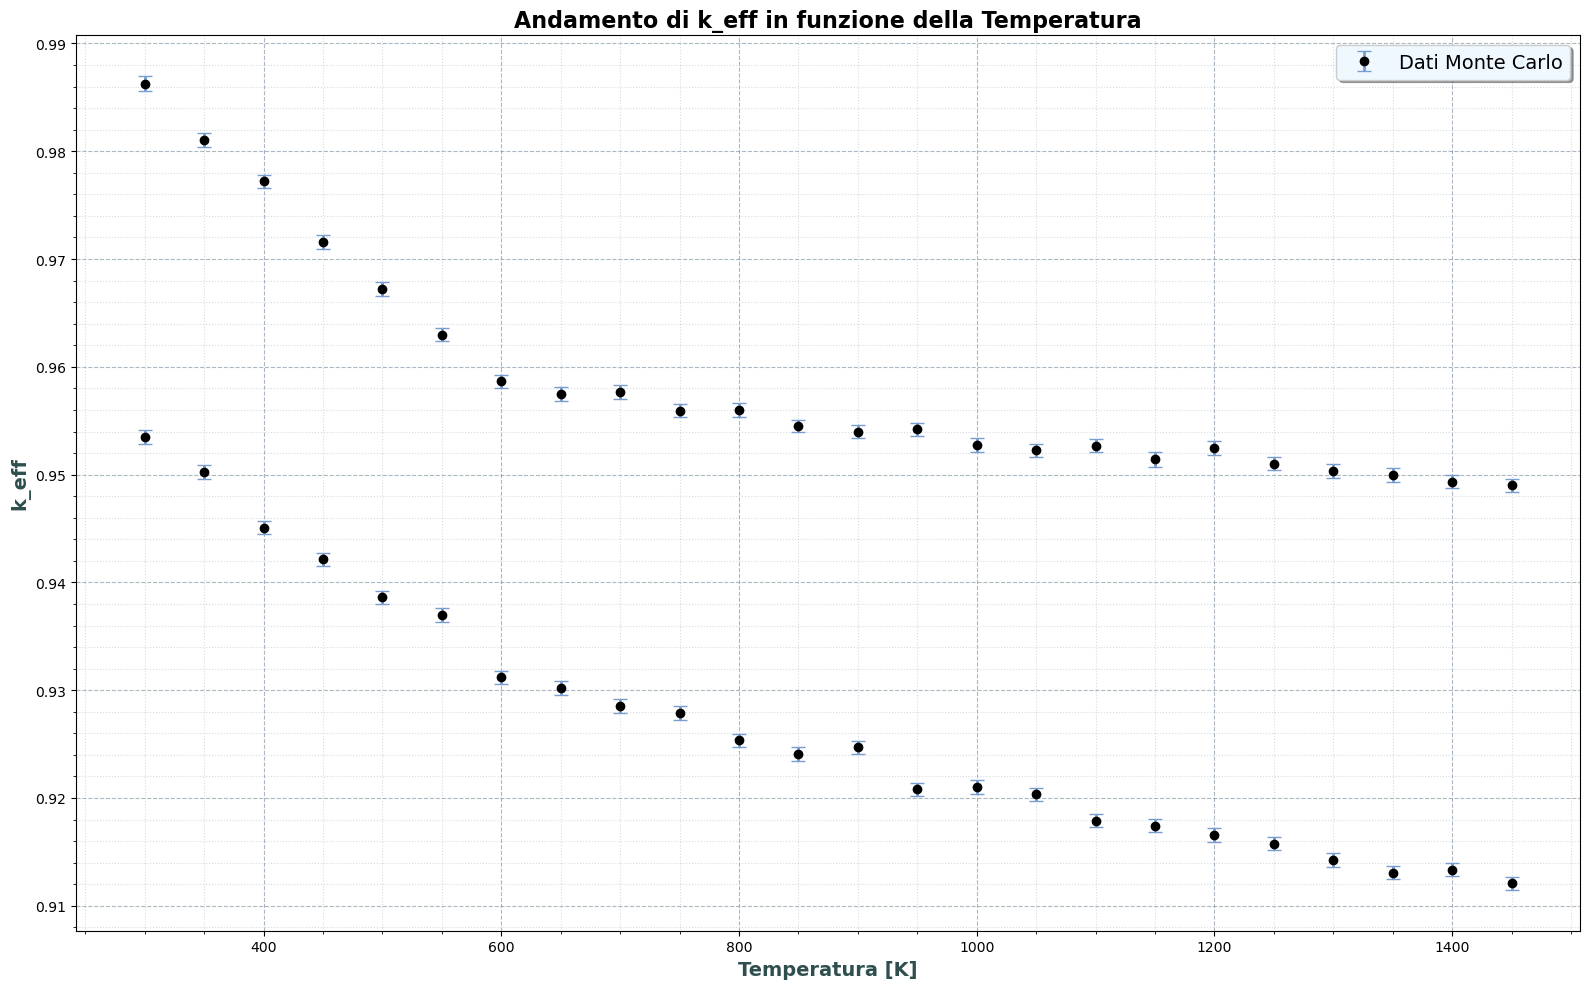

In [29]:
# --- 1. LETTURA DEL FILE result.txt ---
filename = "single_result.txt"
temps = []
k_effs = []
stds = []

# Parser robusto: salta l'header e legge solo le righe che iniziano con numeri
with open(filename, 'r') as f:
    for line in f:
        line = line.strip()
        if not line: continue
        # Se il primo carattere è un numero, assumiamo sia una riga dati
        if line[0].isdigit():
            parts = line.split()
            if len(parts) >= 3:
                temps.append(float(parts[0]))
                k_effs.append(float(parts[1]))
                stds.append(float(parts[2]))

T_data = np.array(temps)
k_data = np.array(k_effs)
err_data = np.array(stds)

# pcm = (k_data - 1)/(10e-5*k_data)     NON è STRADA CORRETTA

# --- 3. PLOTTING (Stile Unificato) ---
fig, ax = plt.subplots(figsize=(16, 10))

# Plot dei dati con barre d'errore
ax.errorbar(T_data, k_data, yerr=err_data, 
            fmt='o',                  # Punti senza linea di congiunzione
            color='#000000',          # Colore punti
            ecolor='#789DD1',         # Colore barre errore
            elinewidth=2,             # Spessore barre
            capsize=5,                # Cappuccetto barre
            label='Dati Monte Carlo',
            zorder=5)

# Formattazione Stile
font_labels = {'fontsize': 14, 'fontweight': 'bold', 'color': '#2F4F4F'}

ax.set_xlabel('Temperatura [K]', **font_labels)
ax.set_ylabel('k_eff', **font_labels)
ax.set_title('Andamento di k_eff in funzione della Temperatura', fontsize=16, fontweight='bold')

# Griglia
ax.minorticks_on()
ax.grid(which='major', linestyle='--', alpha=0.6, color='#778899')
ax.grid(which='minor', linestyle=':', alpha=0.3, color='#778899')

# Legenda
ax.legend(loc='upper right', frameon=True, shadow=True, fontsize=14, facecolor='#F0F8FF')

plt.tight_layout()
plt.show()

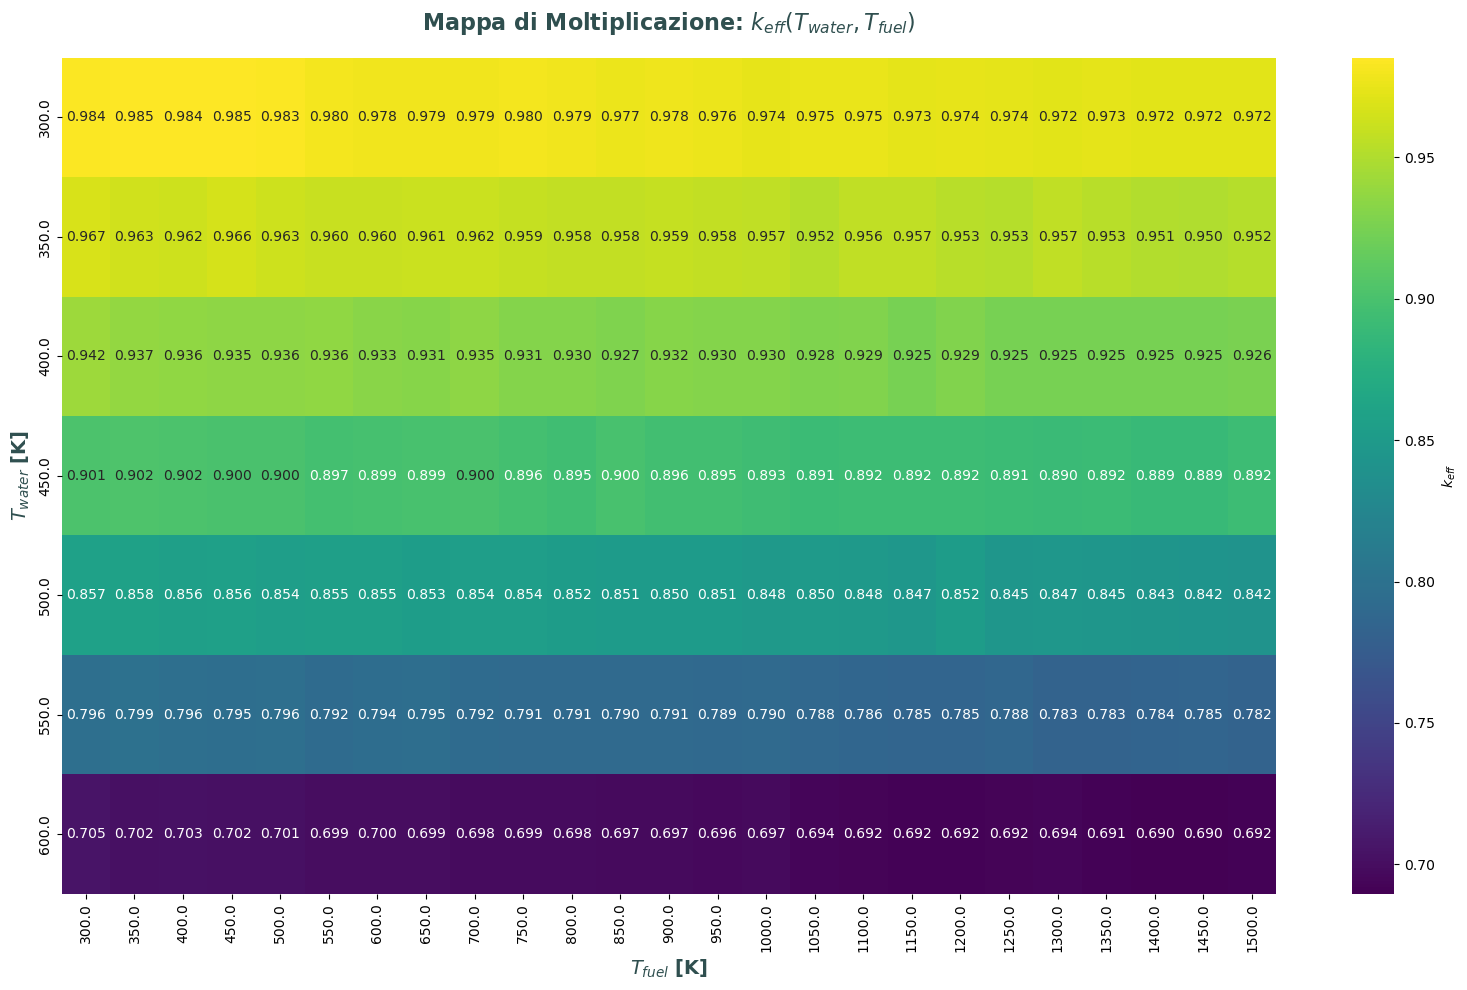

In [30]:
# 1. Parsing robusto del file di output
data = []
with open("result.txt", "r") as f:
    for line in f:
        parts = line.strip().split()
        # Isolamento delle righe contenenti le 4 grandezze fisiche
        if len(parts) == 4:
            try:
                t_w = float(parts[0])
                t_f = float(parts[1])
                k = float(parts[2])
                err = float(parts[3])
                data.append([t_w, t_f, k, err])
            except ValueError:
                continue

df = pd.DataFrame(data, columns=['T_water', 'T_fuel', 'k_eff', 'std_dev'])

# 2. Vettorizzazione 2D per la heatmap
heatmap_data = df.pivot(index='T_water', columns='T_fuel', values='k_eff')

# 3. Setup del plot (Standard Layout)
fig, ax = plt.subplots(figsize=(16, 10))

# Mappatura termica
sns.heatmap(heatmap_data, annot=True, fmt=".3f", cmap="viridis", ax=ax,
            cbar_kws={'label': '$k_{eff}$'})

# Formattazione Titolo e Labels
ax.set_title("Mappa di Moltiplicazione: $k_{eff}(T_{water}, T_{fuel})$", fontsize=16, fontweight='bold', color='#2F4F4F', pad=20)
ax.set_xlabel("$T_{fuel}$ [K]", fontsize=14, fontweight='bold', color='#2F4F4F')
ax.set_ylabel("$T_{water}$ [K]", fontsize=14, fontweight='bold', color='#2F4F4F')

plt.tight_layout()
plt.show()